# Week 2: Exploratory Data Analysis and Visualization

### Project: Supermarket Sales Analysis
### Name: Nandita Manna
### Internship: YuvaIntern
### Tools: Python, Pandas, Matplotlib, **Seaborn**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:

from google.colab import files

uploaded = files.upload()

Saving supermarket_sales.csv to supermarket_sales.csv


In [3]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 1000
Number of Columns: 17

Column Names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total 

In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Duplicate Rows: 0


In [6]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [7]:
df.dtypes

,0
Invoice ID,object
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Total,float64


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()

df[['Date', 'Month', 'Day', 'Day_Name']].head()

,Date,Month,Day,Day_Name
0,2019-01-05,1,5,Saturday
1,2019-03-08,3,8,Friday
2,2019-03-03,3,3,Sunday
3,2019-01-27,1,27,Sunday
4,2019-02-08,2,8,Friday


In [9]:
df['Sales_Category'] = pd.cut(
    df['Total'],
    bins=[0, 200, 400, 600, 1000],
    labels=['Low', 'Medium', 'High', 'Very High']
)

df[['Total', 'Sales_Category']].head()

,Total,Sales_Category
0,548.9715,High
1,80.2200,Low
2,340.5255,Medium
3,489.0480,High
4,634.3785,Very High


In [10]:
product_sales = (
    df.groupby('Product line')['Total']
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64


In [11]:
branch_sales = (
    df.groupby('Branch')['Total']
    .sum()
    .sort_values(ascending=False)
)

print(branch_sales)

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64


In [12]:
payment_sales = (
    df.groupby('Payment')['Total']
    .sum()
    .sort_values(ascending=False)
)

print(payment_sales)

Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Total, dtype: float64


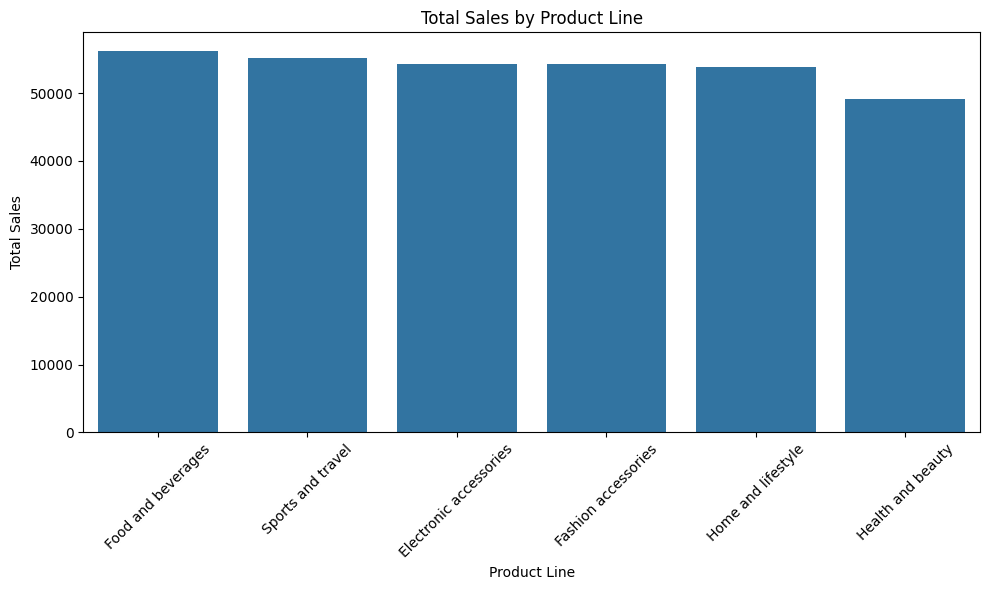

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_sales.index,
    y=product_sales.values
)

plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

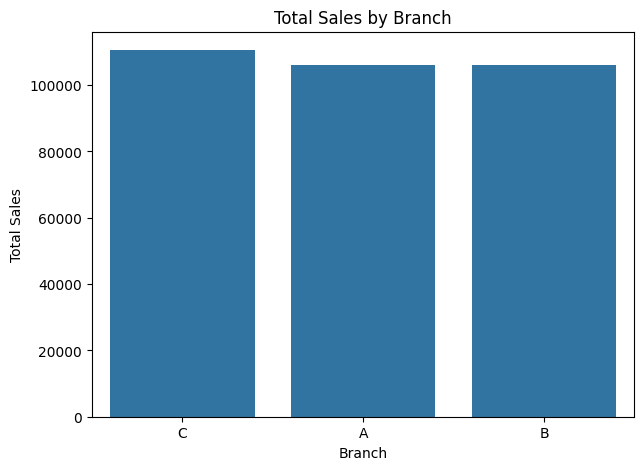

In [14]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=branch_sales.index,
    y=branch_sales.values
)

plt.title('Total Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')
plt.show()

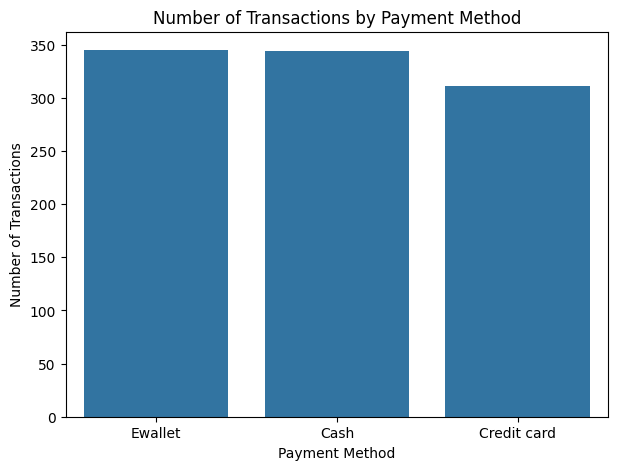

In [15]:
payment_count = df['Payment'].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=payment_count.index,
    y=payment_count.values
)

plt.title('Number of Transactions by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.show()

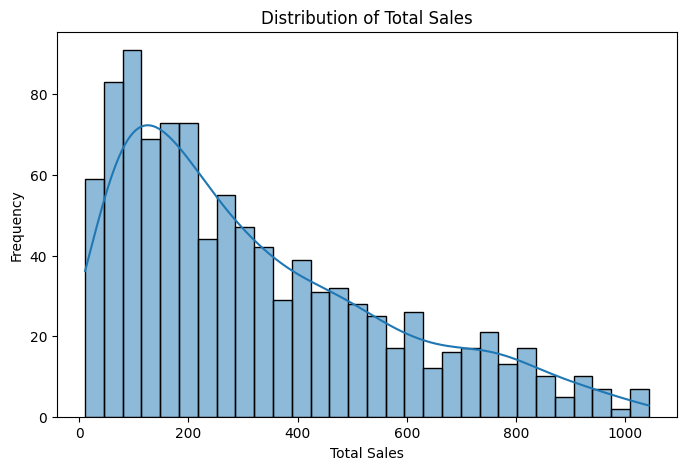

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Total'], bins=30, kde=True)

plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

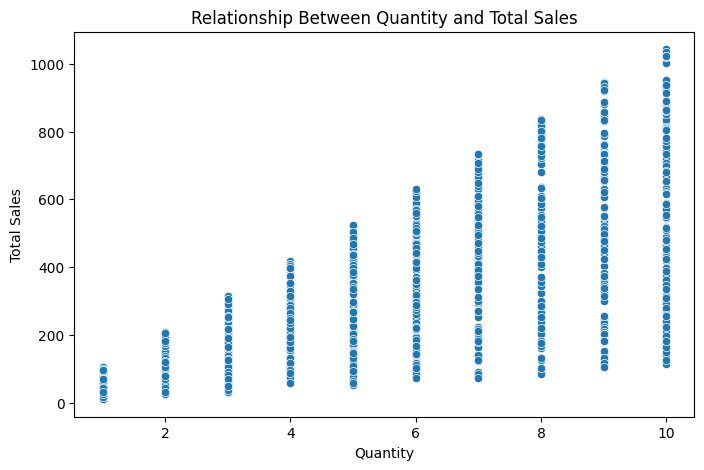

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total'
)

plt.title('Relationship Between Quantity and Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.show()

In [18]:
numeric_data = df.select_dtypes(include=np.number)

correlation = numeric_data.corr()

print(correlation)

                         Unit price  Quantity    Tax 5%     Total      cogs  \
Unit price                 1.000000  0.010778  0.633962  0.633962  0.633962   
Quantity                   0.010778  1.000000  0.705510  0.705510  0.705510   
Tax 5%                     0.633962  0.705510  1.000000  1.000000  1.000000   
Total                      0.633962  0.705510  1.000000  1.000000  1.000000   
cogs                       0.633962  0.705510  1.000000  1.000000  1.000000   
gross margin percentage         NaN       NaN       NaN       NaN       NaN   
gross income               0.633962  0.705510  1.000000  1.000000  1.000000   
Rating                    -0.008778 -0.015815 -0.036442 -0.036442 -0.036442   
Month                     -0.027387 -0.014524 -0.022301 -0.022301 -0.022301   
Day                        0.057021 -0.043347 -0.002515 -0.002515 -0.002515   

                         gross margin percentage  gross income    Rating  \
Unit price                                   NaN      

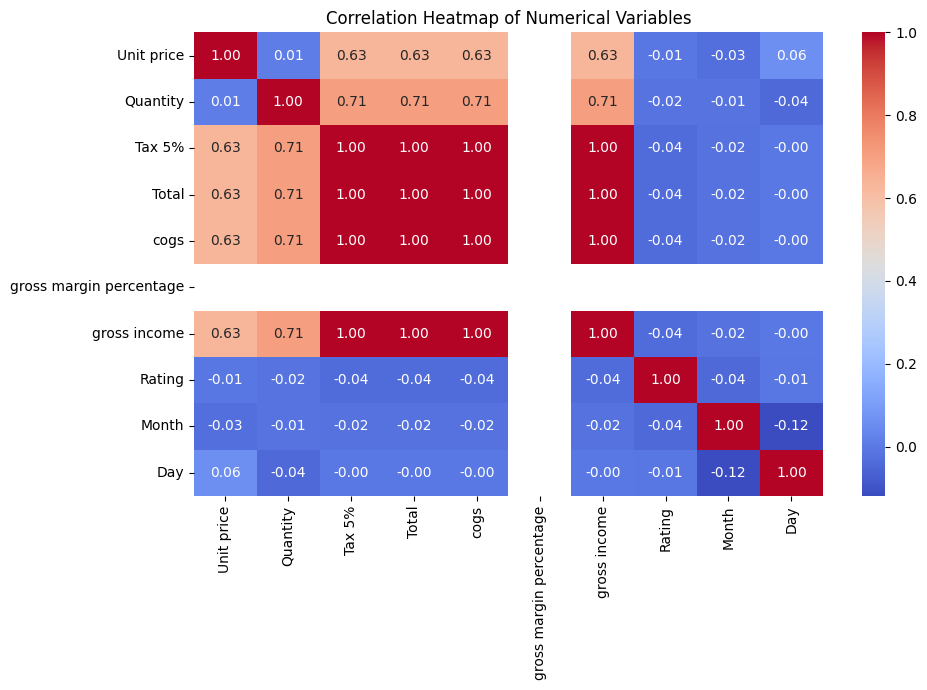

In [19]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

In [20]:
correlation_with_total = (
    correlation['Total']
    .sort_values(ascending=False)
)

print("Correlation with Total Sales:")
print(correlation_with_total)

Correlation with Total Sales:
Total                      1.000000
gross income               1.000000
Tax 5%                     1.000000
cogs                       1.000000
Quantity                   0.705510
Unit price                 0.633962
Day                       -0.002515
Month                     -0.022301
Rating                    -0.036442
gross margin percentage         NaN
Name: Total, dtype: float64


In [21]:
rating_by_product = (
    df.groupby('Product line')['Rating']
    .mean()
    .sort_values(ascending=False)
)

print(rating_by_product)

Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64


In [22]:
customer_sales = (
    df.groupby('Customer type')['Total']
    .agg(['sum', 'mean', 'count'])
)

print(customer_sales)

                      sum        mean  count
Customer type                               
Member         164223.444  327.791305    501
Normal         158743.305  318.122856    499


In [23]:
print("KEY INSIGHTS")
print("-" * 50)

print("1. Highest-selling product line:",
      product_sales.idxmax())

print("2. Lowest-selling product line:",
      product_sales.idxmin())

print("3. Highest-performing branch:",
      branch_sales.idxmax())

print("4. Most-used payment method:",
      payment_count.idxmax())

print("5. Product line with highest average rating:",
      rating_by_product.idxmax())

print("6. Customer type with highest average sales:",
      customer_sales['mean'].idxmax())

KEY INSIGHTS
--------------------------------------------------
1. Highest-selling product line: Food and beverages
2. Lowest-selling product line: Health and beauty
3. Highest-performing branch: C
4. Most-used payment method: Ewallet
5. Product line with highest average rating: Food and beverages
6. Customer type with highest average sales: Member


## Conclusion

The Exploratory Data Analysis of the Supermarket Sales dataset helped identify important patterns in sales, customer behaviour, product performance, payment methods, and numerical relationships. Data cleaning, transformation, aggregation, and visualization were performed to understand the dataset in detail. Correlation analysis was also used to examine relationships among numerical variables. The findings can help businesses understand customer preferences, product demand, and sales performance for better decision-making.

In [24]:
print("EDA ANALYSIS COMPLETED")
print("=" * 50)

print("Dataset contains", df.shape[0], "rows and", df.shape[1], "columns.")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Highest-selling product line:", product_sales.idxmax())
print("Highest-performing branch:", branch_sales.idxmax())
print("Most-used payment method:", payment_count.idxmax())
print("Highest-rated product line:", rating_by_product.idxmax())

EDA ANALYSIS COMPLETED
Dataset contains 1000 rows and 21 columns.
Missing values: 9
Duplicate rows: 0
Highest-selling product line: Food and beverages
Highest-performing branch: C
Most-used payment method: Ewallet
Highest-rated product line: Food and beverages


## Conclusion

The Exploratory Data Analysis of the Supermarket Sales dataset helped identify important patterns in sales, customer behaviour, product performance, payment methods, and numerical relationships. Data cleaning, transformation, aggregation, and visualization were performed to understand the dataset in detail. Correlation analysis was also used to examine relationships among numerical variables. The findings can help businesses understand customer preferences, product demand, and sales performance for better decision-making.

In [25]:
print("EDA ANALYSIS COMPLETED")
print("=" * 50)

print("Dataset:", df.shape[0], "rows and", df.shape[1], "columns")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Highest-selling product line:", product_sales.idxmax())
print("Lowest-selling product line:", product_sales.idxmin())
print("Highest-performing branch:", branch_sales.idxmax())
print("Most-used payment method:", payment_count.idxmax())
print("Highest-rated product line:", rating_by_product.idxmax())
print("Customer type with highest average sales:", customer_sales['mean'].idxmax())

EDA ANALYSIS COMPLETED
Dataset: 1000 rows and 21 columns
Missing values: 9
Duplicate rows: 0
Highest-selling product line: Food and beverages
Lowest-selling product line: Health and beauty
Highest-performing branch: C
Most-used payment method: Ewallet
Highest-rated product line: Food and beverages
Customer type with highest average sales: Member
